In [6]:
from astropy.table import Table
from astropy.io import fits
from collections import Counter

import matplotlib.pyplot as plt

catalog_dir = "/home/alab_student/Tim/Projects/MeV_Blazars/Data/"
outdir = '/home/alab_student/Tim/Projects/MeV_Blazars/Outputs'

# Forecasting for Cross-Matched Sources

In [7]:
# Import flux estimates from SED modeling of cross matched sources.

MeV_Blazar_Catalog_SED_Fits = Table.read(catalog_dir + "MeV_Blazar_Catalog_v2_SED_Fits.fits")
Mask = (MeV_Blazar_Catalog_SED_Fits['MeV_Model'] != 'None')
MeV_Blazar_Catalog_SED_Fits = MeV_Blazar_Catalog_SED_Fits[Mask]

MeV_Estimated_Fluxes = [list(x) for x in MeV_Blazar_Catalog_SED_Fits['MeV_Flux_Estimates'].tolist()]
Blazar_Classes = MeV_Blazar_Catalog_SED_Fits['Fermi_Type'].tolist()
MeV_Flux_Estimates_By_Band = list(zip(*MeV_Estimated_Fluxes))

FSRQ_Flux_Estimates = list(zip(*[MeV_Estimated_Fluxes[i] for i in range(len(MeV_Estimated_Fluxes)) if Blazar_Classes[i].upper() == 'FSRQ']))
BLL_Flux_Estimates = list(zip(*[MeV_Estimated_Fluxes[i] for i in range(len(MeV_Estimated_Fluxes)) if Blazar_Classes[i].upper() == 'BLL']))

In [8]:
# Sensitivity limit requirements for source detection.

print(f"Sensitivity limit required to detect one blazar at one energy: {max(max(sublist) for sublist in MeV_Flux_Estimates_By_Band):.2e} erg/cm^2/s") 
print(f"Sensitivity limit required to detect all blazars at all energies: {min(min(sublist) for sublist in MeV_Flux_Estimates_By_Band):.2e} erg/cm^2/s")
print("")
print(f"Sensitivity limit required to detect one FSRQ at one energy: {max(max(sublist) for sublist in FSRQ_Flux_Estimates):.2e} erg/cm^2/s") 
print(f"Sensitivity limit required to detect all FSRQs at all energies: {min(min(sublist) for sublist in FSRQ_Flux_Estimates):.2e} erg/cm^2/s")
print("")
print(f"Sensitivity limit required to detect one BL Lac at one energy: {max(max(sublist) for sublist in BLL_Flux_Estimates):.2e} erg/cm^2/s") 
print(f"Sensitivity limit required to detect all BL Lacs at all energies: {min(min(sublist) for sublist in BLL_Flux_Estimates):.2e} erg/cm^2/s")

Sensitivity limit required to detect one blazar at one energy: 3.93e-10 erg/cm^2/s
Sensitivity limit required to detect all blazars at all energies: 1.64e-14 erg/cm^2/s

Sensitivity limit required to detect one FSRQ at one energy: 3.93e-10 erg/cm^2/s
Sensitivity limit required to detect all FSRQs at all energies: 5.30e-13 erg/cm^2/s

Sensitivity limit required to detect one BL Lac at one energy: 8.67e-11 erg/cm^2/s
Sensitivity limit required to detect all BL Lacs at all energies: 1.64e-14 erg/cm^2/s


In [9]:
# Source counts for different orders of magnitude sensitivity limits.

N_10_10_all = [len([x for x in MeV_Flux_Estimates_By_Band[i] if x >= 1e-10]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_10_FSRQ = [len([x for x in FSRQ_Flux_Estimates[i] if x >= 1e-10]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_10_BLL = [len([x for x in BLL_Flux_Estimates[i] if x >= 1e-10]) for i in range(len(MeV_Flux_Estimates_By_Band))]

N_10_11_all = [len([x for x in MeV_Flux_Estimates_By_Band[i] if x >= 1e-11]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_11_FSRQ = [len([x for x in FSRQ_Flux_Estimates[i] if x >= 1e-11]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_11_BLL = [len([x for x in BLL_Flux_Estimates[i] if x >= 1e-11]) for i in range(len(MeV_Flux_Estimates_By_Band))]

N_10_12_all = [len([x for x in MeV_Flux_Estimates_By_Band[i] if x >= 1e-12]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_12_FSRQ = [len([x for x in FSRQ_Flux_Estimates[i] if x >= 1e-12]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_12_BLL = [len([x for x in BLL_Flux_Estimates[i] if x >= 1e-12]) for i in range(len(MeV_Flux_Estimates_By_Band))]

print(f"N(>10e-10), all: {N_10_10_all}")
print(f"N(>10e-10), FSRQ: {N_10_10_FSRQ}")
print(f"N(>10e-10), BLL: {N_10_10_BLL}")
print("")
print(f"N(>10e-11), all: {N_10_11_all}")
print(f"N(>10e-11), FSRQ: {N_10_11_FSRQ}")
print(f"N(>10e-11), BLL: {N_10_11_BLL}")
print("")
print(f"N(>10e-12), all: {N_10_12_all}")
print(f"N(>10e-12), FSRQ: {N_10_12_FSRQ}")
print(f"N(>10e-12), BLL: {N_10_12_BLL}")

N(>10e-10), all: [2, 3, 3, 5, 6, 6, 6, 5, 5]
N(>10e-10), FSRQ: [2, 3, 3, 5, 6, 6, 6, 5, 5]
N(>10e-10), BLL: [0, 0, 0, 0, 0, 0, 0, 0, 0]

N(>10e-11), all: [42, 52, 55, 58, 60, 58, 54, 49, 47]
N(>10e-11), FSRQ: [36, 44, 46, 48, 48, 47, 44, 39, 37]
N(>10e-11), BLL: [4, 6, 7, 7, 9, 9, 9, 9, 9]

N(>10e-12), all: [105, 102, 97, 92, 87, 88, 88, 87, 86]
N(>10e-12), FSRQ: [59, 60, 60, 60, 60, 60, 60, 60, 59]
N(>10e-12), BLL: [36, 32, 28, 23, 20, 21, 21, 20, 20]


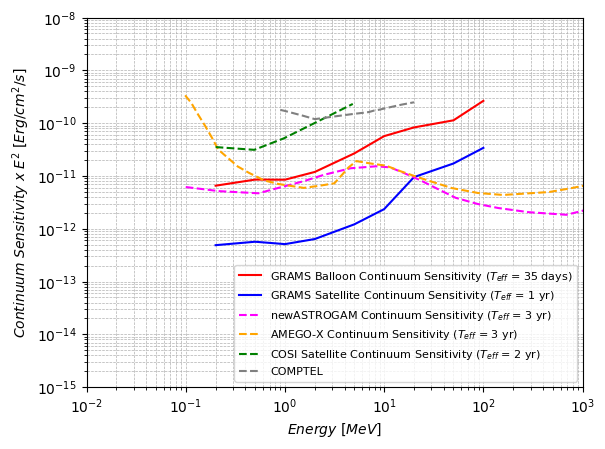

In [10]:
# Import Sensitivity Information for GRAMS Balloon, GRAMS Satellite, AMEGO-X, newASTROGAM, and COSI.

# GRAMS Balloon and Satellite: https://arxiv.org/pdf/1901.03430 (Figure 7.)
# AMEGO-X: https://arxiv.org/pdf/2208.04990 (Figure 3.)
# newASTROGAM: https://arxiv.org/pdf/2507.08133 (Figure 1.)
# COSI: https://arxiv.org/pdf/2308.12362 (Right Panel, Figure 2.)

Sensitivity_Curves_Table = Table.read(catalog_dir + 'Sensitivity_Curves_Data.csv')

GRAMS_Balloon_Energy = Sensitivity_Curves_Table['_GRAMS_Balloon_x'].tolist()[:9]
GRAMS_Balloon_Sensitivity = Sensitivity_Curves_Table['_GRAMS_Balloon_y'].tolist()[:9]

GRAMS_Satellite_Energy = Sensitivity_Curves_Table['_GRAMS_Satellite_x'].tolist()[:9]
GRAMS_Satellite_Sensitivity = Sensitivity_Curves_Table['_GRAMS_Satellite_y'].tolist()[:9]

newASTROGAM_energy_full = Sensitivity_Curves_Table['_newASTROGAM_x'].tolist()
newASTROGAM_sensitivity_full = Sensitivity_Curves_Table['_newASTROGAM_y'].tolist()

AMEGO_X_energy_full = Sensitivity_Curves_Table['_AMEGO_X_x'].tolist()
AMEGO_X_sensitivity_full = Sensitivity_Curves_Table['_AMEGO_X_y'].tolist()

COSI_Satellite_energy = Sensitivity_Curves_Table['_COSI_Satellite_x'].tolist()
COSI_Satellite_sensitivity = Sensitivity_Curves_Table['_COSI_Satellite_y'].tolist()

COMPTEL_energy = Sensitivity_Curves_Table['COMPTEL_x'].tolist()
COMPTEL_sensitivity = Sensitivity_Curves_Table['COMPTEL_y'].tolist()

plt.plot(GRAMS_Balloon_Energy, GRAMS_Balloon_Sensitivity, color='red', label=r'GRAMS Balloon Continuum Sensitivity ($T_{eff}$ = 35 days)', markersize=3)
plt.plot(GRAMS_Satellite_Energy, GRAMS_Satellite_Sensitivity, color='blue', label=r'GRAMS Satellite Continuum Sensitivity ($T_{eff}$ = 1 yr)', markersize=3)
plt.plot(newASTROGAM_energy_full, newASTROGAM_sensitivity_full, color='magenta',label=r'newASTROGAM Continuum Sensitivity ($T_{eff}$ = 3 yr)',markersize=3,linestyle='--')
plt.plot(AMEGO_X_energy_full, AMEGO_X_sensitivity_full, color='orange',label=r'AMEGO-X Continuum Sensitivity ($T_{eff}$ = 3 yr)',markersize=3,linestyle='--')
plt.plot(COSI_Satellite_energy, COSI_Satellite_sensitivity, color='green',label=r'COSI Satellite Continuum Sensitivity ($T_{eff}$ = 2 yr)',markersize=3,linestyle='--')
plt.plot(COMPTEL_energy, COMPTEL_sensitivity, color = 'grey',label=r'COMPTEL',linestyle='--')

plt.xlabel(r'$Energy$ $[MeV]$')
plt.ylabel(r'$ Continuum$ $Sensitivity$ $x$ $E^{2}$ $[Erg/cm^{2}/s]$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-2,1e3)
plt.ylim(1e-15,1e-8)
plt.legend(loc = 'lower right', fontsize=8)
plt.grid(which='both', linestyle='--', linewidth=0.5)


In [11]:
# Sensitivity values at 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, and 100.0 MeV

Sensitivity_Data = Table.read(catalog_dir + 'Sensitivity_Data_Table.fits')

Select_Energy_Values = Sensitivity_Data['Energy'].tolist()
GRAMS_Balloon_Sensitivity = Sensitivity_Data['GRAMS_Balloon_Sensitivity'].tolist()
GRAMS_Satellite_Sensitivity = Sensitivity_Data['GRAMS_Satellite_Sensitivity'].tolist()
AMEGO_X_Sensitivity = Sensitivity_Data['AMEGO_X_Sensitivity'].tolist()
newASTROGAM_Sensitivity = Sensitivity_Data['newASTROGAM_Sensitivity'].tolist()
COSI_Sensitivity = Sensitivity_Data['COSI_Sensitivity'].tolist()

In [12]:
# Compute counts for each instrument

N_GRAMS_Balloon = [sum([x >= GRAMS_Balloon_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_GRAMS_Satellite = [sum([x >= GRAMS_Satellite_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_AMEGO_X = [sum([x >= AMEGO_X_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_newASTROGAM = [sum([x >= newASTROGAM_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_COSI = [sum([x >= COSI_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]

N_S_Intruments_Table = Table([Select_Energy_Values, GRAMS_Balloon_Sensitivity, N_GRAMS_Balloon, GRAMS_Satellite_Sensitivity, N_GRAMS_Satellite, newASTROGAM_Sensitivity, N_newASTROGAM, AMEGO_X_Sensitivity, N_AMEGO_X, COSI_Sensitivity, N_COSI], names=['Energy', 'S_GRAMS_Balloon', 'N_GRAMS_Balloon', 'S_GRAMS_Satellite', 'N_GRAMS_Satellite', 'S_newASTROGAM', 'N_newASTROGAM', 'S_AMEGO_X', 'N_AMEGO_X', 'S_COSI', 'N_COSI'])
N_S_Intruments_Table.pprint_all()

Energy S_GRAMS_Balloon N_GRAMS_Balloon S_GRAMS_Satellite N_GRAMS_Satellite S_newASTROGAM N_newASTROGAM S_AMEGO_X N_AMEGO_X  S_COSI  N_COSI
------ --------------- --------------- ----------------- ----------------- ------------- ------------- --------- --------- -------- ------
   0.2        6.53e-12              60          4.88e-13               111      5.26e-12            69  3.61e-11         6 3.52e-11      6
   0.5        8.52e-12              55          5.67e-13               107      4.69e-12            73  9.52e-12        53 3.12e-11     10
   1.0        8.48e-12              61          5.11e-13               106      6.37e-12            67  6.65e-12        67 5.13e-11      8
   2.0        1.19e-11              51          6.38e-13               100      9.44e-12            59  6.28e-12        69  9.8e-11      5
   5.0        2.67e-11              27          1.21e-12                87      1.43e-11            46  1.88e-11        39 2.31e-10      1
  10.0        5.67e-11     

In [13]:
# Individual source detectability by each instrument

Names = MeV_Blazar_Catalog_SED_Fits['Fermi_Counterpart_Name'].tolist()

GRAMS_Balloon_Detectable_Energies = []
GRAMS_Satellite_Detectable_Energies = []
newASTROGAM_Detectable_Energies = []
AMEGO_X_Detectable_Energies = []

for i in range(len(Names)):
    GRAMS_Balloon_Detectable_Energies.append([Select_Energy_Values[x] for x in range(len(Select_Energy_Values)) if MeV_Estimated_Fluxes[i][x] >= GRAMS_Balloon_Sensitivity[x]])
    GRAMS_Satellite_Detectable_Energies.append([Select_Energy_Values[x] for x in range(len(Select_Energy_Values)) if MeV_Estimated_Fluxes[i][x] >= GRAMS_Satellite_Sensitivity[x]])
    newASTROGAM_Detectable_Energies.append([Select_Energy_Values[x] for x in range(len(Select_Energy_Values)) if MeV_Estimated_Fluxes[i][x] >= newASTROGAM_Sensitivity[x]])
    AMEGO_X_Detectable_Energies.append([Select_Energy_Values[x] for x in range(len(Select_Energy_Values)) if MeV_Estimated_Fluxes[i][x] >= AMEGO_X_Sensitivity[x]])
    
Source_Detectability_Table = Table([Names, GRAMS_Balloon_Detectable_Energies, GRAMS_Satellite_Detectable_Energies, newASTROGAM_Detectable_Energies, AMEGO_X_Detectable_Energies], names=['Name', 'GRAMS_Balloon_Detectable_Energies', 'GRAMS_Satellite_Detectable_Energies', 'newASTROGAM_Detectable_Energies', 'AMEGO_X_Detectable_Energies'])
Source_Detectability_Table.pprint_all()


          Name                  GRAMS_Balloon_Detectable_Energies                 GRAMS_Satellite_Detectable_Energies                  newASTROGAM_Detectable_Energies                      AMEGO_X_Detectable_Energies            
----------------------- -------------------------------------------------- -------------------------------------------------- -------------------------------------------------- --------------------------------------------------
           1ES 0033+595                                              [0.2]                          [0.2, 0.5, 1.0, 2.0, 5.0]                                         [0.2, 0.5]                                                 []
           1ES 0120+340                                                 []                                    [0.2, 0.5, 1.0]                                                 []                                                 []
            B3 0133+388                                                 []              

In [14]:
# Determine brightest blazars in MeV.

Brightest_Blazars = [[] for _ in range(18)]
Blazar_Names = MeV_Blazar_Catalog_SED_Fits['Fermi_Counterpart_Name'].tolist()

Names_brightest_instances = []

for i in range(len(MeV_Flux_Estimates_By_Band)):
    names_fluxes = list(zip(Blazar_Names, MeV_Flux_Estimates_By_Band[i]))
    top10 = [x for x in sorted(names_fluxes, key=lambda x: x[1], reverse=True)][:10]
    for x in range(len(top10)):
        Brightest_Blazars[2*i].append(top10[x][0])
        Brightest_Blazars[2*i+1].append(top10[x][1])
        Names_brightest_instances.append(top10[x][0])

    
print(Counter(Names_brightest_instances))

Brightest_Blazars_Table = Table(Brightest_Blazars, names=['Name_0_2', 'Flux_0_2', 'Name_0_5', 'Flux_0_5', 'Name_1_0', 'Flux_1_0', 'Name_2_0', 'Flux_2_0', 'Name_5_0', 'Flux_5_0', 'Name_10_0', 'Flux_10_0', 'Name_20_0', 'Flux_20_0', 'Name_50_0', 'Flux_50_0', 'Name_100_0', 'Flux_100_0'])
Brightest_Blazars_Table.pprint_all()

Counter({'3C 273': 9, '3C 454.3': 9, 'PKS 1830-211': 9, 'PKS 1510-089': 9, '3C 279': 9, 'CTA 102': 9, '4C +71.07': 8, 'BL Lac': 8, 'PKS 2149-306': 6, '4C +21.35': 6, '2MASS J16561677-3302127': 3, '4C +38.41': 3, 'NRAO 140': 1, 'PKS 0402-362': 1})
        Name_0_2               Flux_0_2                Name_0_5               Flux_0_5                Name_1_0               Flux_1_0          Name_2_0          Flux_2_0          Name_5_0          Flux_5_0         Name_10_0         Flux_10_0         Name_20_0         Flux_20_0         Name_50_0         Flux_50_0         Name_100_0        Flux_100_0      
----------------------- ---------------------- ----------------------- ---------------------- ----------------------- ---------------------- ------------ ---------------------- ------------ ---------------------- ------------ ---------------------- ------------ ---------------------- ------------ ---------------------- ------------ ----------------------
                 3C 273 1.8470358391746

In [15]:
primary_hdu = fits.PrimaryHDU()
N_S_Intruments_Table = fits.BinTableHDU(data=N_S_Intruments_Table, name='TABLE1')
Source_Detectability_Table = fits.BinTableHDU(data=Source_Detectability_Table, name='TABLE2')
Brightest_Blazars_Table = fits.BinTableHDU(data=Brightest_Blazars_Table, name='TABLE3')

Cross_Match_Forecast_Table = fits.HDUList([primary_hdu, N_S_Intruments_Table, Source_Detectability_Table])
Cross_Match_Forecast_Table.writeto(catalog_dir + 'MeV_Instruments_Matched_Blazar_Forecast.fits', overwrite=True)

# Forecasting from Luminosity Function Models

In [ ]:
Monochromatic_Luminosity_Function_Table_New = Table.read(catalog_dir + 'N_S_LF_Output.fits')
#Monochromatic_Luminosity_Function_Table_New.pprint_all()

Monochromatic_sensitivity_list_new = Monochromatic_Luminosity_Function_Table_New['Sensitivity'].tolist()

Mono_Toda_LF_New = [Monochromatic_Luminosity_Function_Table_New.columns[i].tolist() for i in [1,2,3,4,5,6,7,8,9]]
Mono_Rajguru_LF_New = [Monochromatic_Luminosity_Function_Table_New.columns[i].tolist() for i in [10,11,12,13,14,15,16,17,18]]
Mono_Marcotulli_LF_New = [Monochromatic_Luminosity_Function_Table_New.columns[i].tolist() for i in [19,20,21,22,23,24,25,26,27]]
Mono_Ajello_LF_New = [Monochromatic_Luminosity_Function_Table_New.columns[i].tolist() for i in [28,29,30,31,32,33,34,35,36]]

FileNotFoundError: [Errno 2] No such file or directory: '/home/alab_student/Tim/Projects/MeV_Blazars/Data/Monochromatic_Luminosity_Function_Results.fits'

In [ ]:
Toda_10_10_New = []
Toda_10_11_New = []
Toda_10_12_New = []
Rajguru_10_10_New = []
Rajguru_10_11_New = []
Rajguru_10_12_New = []
Ajello_10_10_New = []
Ajello_10_11_New = []
Ajello_10_12_New = []
Marcotulli_10_10_New = []
Marcotulli_10_11_New = []
Marcotulli_10_12_New = []

for i in range(len(Select_Energy_Values)):
    
    for x in range(len(Monochromatic_sensitivity_list_new)):
        if Monochromatic_sensitivity_list_new[x] == 1e-10:
            Toda_10_10_New.append(round(Mono_Toda_LF_New[i][x],0))
            Rajguru_10_10_New.append(round(Mono_Rajguru_LF_New[i][x],0))
            Ajello_10_10_New.append(round(Mono_Ajello_LF_New[i][x],0))
            Marcotulli_10_10_New.append(round(Mono_Marcotulli_LF_New[i][x],0))
        if Monochromatic_sensitivity_list_new[x] == 1e-11:
            Toda_10_11_New.append(round(Mono_Toda_LF_New[i][x],0))
            Rajguru_10_11_New.append(round(Mono_Rajguru_LF_New[i][x],0))
            Ajello_10_11_New.append(round(Mono_Ajello_LF_New[i][x],0))
            Marcotulli_10_11_New.append(round(Mono_Marcotulli_LF_New[i][x],0))
        if Monochromatic_sensitivity_list_new[x] == 1e-12:
            Toda_10_12_New.append(round(Mono_Toda_LF_New[i][x],0))
            Rajguru_10_12_New.append(round(Mono_Rajguru_LF_New[i][x],0))
            Ajello_10_12_New.append(round(Mono_Ajello_LF_New[i][x],0))
            Marcotulli_10_12_New.append(round(Mono_Marcotulli_LF_New[i][x],0))
            
print("Counts for Toda et al 2020")
print(f"N(>10e-11) {Toda_10_11_New}")
print(f"N(>10e-12) {Toda_10_12_New}")
print(" ")
print("Counts for Rajguru et al 2025")
print(f"N(>10e-11) {Rajguru_10_11_New}")
print(f"N(>10e-12) {Rajguru_10_12_New}")
print(" ")
print("Counts for Ajello et al 2013")
print(f"N(>10e-11) {Ajello_10_11_New}")
print(f"N(>10e-12) {Ajello_10_12_New}")
print(" ")
print("Counts for Marcotulli et al 2022")
print(f"N(>10e-11) {Marcotulli_10_11_New}")
print(f"N(>10e-12) {Marcotulli_10_12_New}")

Counts for Toda et al 2020
N(>10e-11) [50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0]
N(>10e-12) [274.0, 274.0, 274.0, 274.0, 274.0, 274.0, 274.0, 274.0, 274.0]
 
Counts for Rajguru et al 2025
N(>10e-11) [418.0, 418.0, 418.0, 418.0, 418.0, 418.0, 418.0, 418.0, 418.0]
N(>10e-12) [948.0, 948.0, 948.0, 948.0, 948.0, 948.0, 948.0, 948.0, 948.0]
 
Counts for Ajello et al 2013
N(>10e-11) [62.0, 62.0, 62.0, 62.0, 62.0, 62.0, 62.0, 62.0, 62.0]
N(>10e-12) [3112.0, 3112.0, 3112.0, 3112.0, 3112.0, 3112.0, 3112.0, 3112.0, 3112.0]
 
Counts for Marcotulli et al 2022
N(>10e-11) [81.0, 81.0, 81.0, 81.0, 81.0, 81.0, 81.0, 81.0, 81.0]
N(>10e-12) [2242.0, 2242.0, 2242.0, 2242.0, 2242.0, 2242.0, 2242.0, 2242.0, 2242.0]


In [ ]:
Sensitivities = [GRAMS_Balloon_Sensitivity, GRAMS_Satellite_Sensitivity, newASTROGAM_Sensitivity, AMEGO_X_Sensitivity]

GRAMS_Balloon_Rajguru = []
GRAMS_Balloon_Marcotulli = []
GRAMS_Balloon_Ajello = []

GRAMS_Satellite_Rajguru = []
GRAMS_Satellite_Marcotulli = []
GRAMS_Satellite_Ajello = []

newASTROGAM_Rajguru = []
newASTROGAM_Marcotulli = []
newASTROGAM_Ajello = []

AMEGO_X_Rajguru = []
AMEGO_X_Marcotulli = []
AMEGO_X_Ajello = []

for x in range(len(Sensitivities)):
    for i in range(len(Sensitivities[x])):
        Index = min(enumerate(Monochromatic_sensitivity_list_new), key=lambda s: abs(Sensitivities[x][i] - s[1]))[0]

        if x == 0:
            GRAMS_Balloon_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index], 0))
            GRAMS_Balloon_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index],0))
            GRAMS_Balloon_Ajello.append(round(Mono_Ajello_LF_New[i][Index],0))
        if x == 1:
            GRAMS_Satellite_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index],0))
            GRAMS_Satellite_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index],0))
            GRAMS_Satellite_Ajello.append(round(Mono_Ajello_LF_New[i][Index],0))
        if x == 2:
            newASTROGAM_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index], 0))
            newASTROGAM_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index],0))
            newASTROGAM_Ajello.append(round(Mono_Ajello_LF_New[i][Index],0))
        if x == 3:
            AMEGO_X_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index],0))
            AMEGO_X_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index],0))
            AMEGO_X_Ajello.append(round(Mono_Ajello_LF_New[i][Index],0))
            
COSI_Rajguru = []
COSI_Marcotulli = []
COSI_Ajello = []
            
for i in range(len(COSI_Sensitivity) - 4):
    Index = min(enumerate(Monochromatic_sensitivity_list_new), key=lambda s: abs(COSI_Sensitivity[i] - s[1]))[0]
    COSI_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index], 0))
    COSI_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index], 0))
    COSI_Ajello.append(round(Mono_Ajello_LF_New[i][Index], 0))
            
print("GRAMS Balloon")     
print(GRAMS_Balloon_Rajguru)
print(GRAMS_Balloon_Marcotulli)
print(GRAMS_Balloon_Ajello)
print("GRAMS Satellite")     
print(GRAMS_Satellite_Rajguru)
print(GRAMS_Satellite_Marcotulli)
print(GRAMS_Satellite_Ajello)
print("newASTROGAM")     
print(newASTROGAM_Rajguru)
print(newASTROGAM_Marcotulli)
print(newASTROGAM_Ajello)
print("AMEGO-X")     
print(AMEGO_X_Rajguru)
print(AMEGO_X_Marcotulli)
print(AMEGO_X_Ajello)
print("COSI")
print(COSI_Rajguru)
print(COSI_Marcotulli)
print(COSI_Ajello)
    

GRAMS Balloon
[541.0, 459.0, 459.0, 377.0, 166.0, 79.0, 52.0, 34.0, 9.0]
[161.0, 102.0, 102.0, 64.0, 16.0, 7.0, 4.0, 3.0, 1.0]
[128.0, 80.0, 80.0, 49.0, 10.0, 3.0, 1.0, 1.0, 0.0]
GRAMS Satellite
[1076.0, 1076.0, 1076.0, 1021.0, 902.0, 769.0, 418.0, 299.0, 166.0]
[6190.0, 6190.0, 6190.0, 3946.0, 1593.0, 637.0, 81.0, 41.0, 16.0]
[9247.0, 9247.0, 9247.0, 5830.0, 2062.0, 622.0, 62.0, 29.0, 10.0]
newASTROGAM
[621.0, 621.0, 541.0, 418.0, 299.0, 299.0, 418.0, 621.0, 769.0]
[254.0, 254.0, 161.0, 81.0, 41.0, 41.0, 81.0, 254.0, 637.0]
[209.0, 209.0, 128.0, 62.0, 29.0, 29.0, 62.0, 209.0, 622.0]
AMEGO-X
[116.0, 418.0, 541.0, 541.0, 299.0, 299.0, 418.0, 541.0, 621.0]
[10.0, 81.0, 161.0, 161.0, 41.0, 41.0, 81.0, 161.0, 254.0]
[5.0, 62.0, 128.0, 128.0, 29.0, 29.0, 62.0, 128.0, 209.0]
COSI
[166.0, 166.0, 79.0, 38.0, 14.0]
[16.0, 16.0, 7.0, 3.0, 1.0]
[10.0, 10.0, 3.0, 1.0, 0.0]
